<a href="https://colab.research.google.com/github/gallegoshernandezcarlosmihael01/MAA_Practicas_3_4_5/blob/main/Pr%C3%A1ctica4Regresi%C3%B3n_polinomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 4. Regresión polinomial**

Gallegos Hernández Carlos Mihael , López Castillejos Aseret Laxhidua

# **Paso 1. Importar las bibliotecas**

In [2]:
# Importar NumPy para generar datos y realizar operaciones matemáticas.
import numpy as np

In [3]:
# Importar Pandas para organizar los datos en tablas.
import pandas as pd


In [4]:
# Importar Matplotlib para crear gráficas.
import matplotlib.pyplot as plt

In [5]:
# Importar la función para dividir los datos en entrenamiento y prueba.
from sklearn.model_selection import train_test_split

In [6]:
# Importar PolynomialFeatures para generar potencias de la variable.
from sklearn.preprocessing import PolynomialFeatures

In [7]:
# Importar StandardScaler para estandarizar la variable de entrada.
from sklearn.preprocessing import StandardScaler

In [8]:
# Importar Pipeline para encadenar las etapas del modelo.
from sklearn.pipeline import Pipeline

In [9]:
# Importar el algoritmo de regresión lineal.
from sklearn.linear_model import LinearRegression

In [11]:
# Importar las métricas para evaluar las predicciones.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# **Paso 2. Simular la temperatura y la respuesta del sensor**

In [12]:
# Fijar una semilla para reproducir los mismos datos en cada ejecución.
np.random.seed(42)
# Generar 250 temperaturas distribuidas entre 0 y 50 °C.
temperatura = np.linspace(0, 50, 250)
# Definir una respuesta no lineal ideal del sensor.
respuesta_ideal = 10 + 1.5 * temperatura + 0.08 * temperatura**2
# Generar ruido aleatorio para simular variaciones de medición.
ruido = np.random.normal(loc=0, scale=8, size=250)
# Sumar el ruido a la respuesta ideal para obtener datos simulados.
respuesta_sensor = respuesta_ideal + ruido
# Organizar las temperaturas y las respuestas en una tabla.
datos = pd.DataFrame({
 "temperatura": temperatura,
 "respuesta_sensor": respuesta_sensor
})
# Mostrar los primeros cinco registros.
display(datos.head())

,temperatura,respuesta_sensor
0,0.000000,13.973713
1,0.200803,9.198316
2,0.401606,15.796821
3,0.602410,23.116885
4,0.803213,9.383204


# **Paso 3. Consultar estadísticas básicas**

In [13]:
# Mostrar la cantidad de filas y columnas del conjunto.
print("Dimensiones:", datos.shape)
# Calcular estadísticas descriptivas de las variables.
display(datos.describe())
# Contar los valores faltantes en cada columna.
print("Valores faltantes:")
print(datos.isnull().sum())

Dimensiones: (250, 2)


,temperatura,respuesta_sensor
count,250.000000,250.000000
mean,25.000000,114.281152
std,14.520678,82.284608
min,0.000000,-0.845427
25%,12.500000,40.973566
50%,25.000000,98.715547
75%,37.500000,178.488744
max,50.000000,297.219229


Valores faltantes:
temperatura         0
respuesta_sensor    0
dtype: int64


# **Paso 4. Graficar la respuesta del sensor**

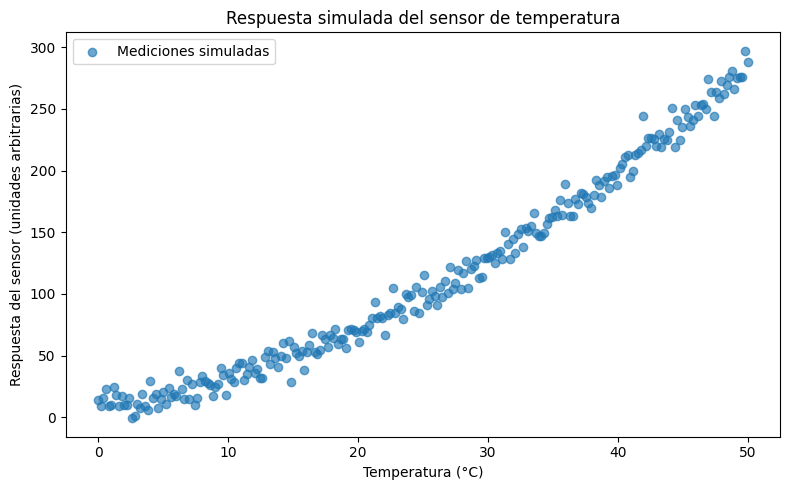

In [14]:
# Crear una figura de 8 pulgadas de ancho por 5 de alto.
plt.figure(figsize=(8, 5))
# Graficar los datos observados como puntos.
plt.scatter(
 datos["temperatura"],
 datos["respuesta_sensor"],
 alpha=0.65,
 label="Mediciones simuladas"
)
# Agregar el título de la gráfica.
plt.title("Respuesta simulada del sensor de temperatura")
# Etiquetar el eje horizontal.
plt.xlabel("Temperatura (°C)")
# Etiquetar el eje vertical.
plt.ylabel("Respuesta del sensor (unidades arbitrarias)")
# Mostrar la leyenda de la gráfica.
plt.legend()
# Ajustar el diseño para evitar superposiciones.
plt.tight_layout()
# Mostrar la gráfica.
plt.show()


# **Paso 5. Separar entrenamiento y prueba**

In [15]:
# Seleccionar la temperatura como variable de entrada.
X = datos[["temperatura"]]
# Seleccionar la respuesta del sensor como variable objetivo.
y = datos["respuesta_sensor"]
# Reservar el 20 % de los registros para la evaluación.
# El 80 % restante se utilizará para entrenar los modelos.
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.20,
 random_state=42
)
# Mostrar la cantidad de registros de entrenamiento.
print("Registros de entrenamiento:", len(X_train))
# Mostrar la cantidad de registros de prueba.
print("Registros de prueba:", len(X_test))

Registros de entrenamiento: 200
Registros de prueba: 50


# **Paso 6. Definir un modelo de grado 2**

In [16]:
# Crear una secuencia de procesamiento para el modelo.
modelo_grado_2 = Pipeline([
 # Estandarizar la temperatura utilizando los datos de entrenamiento.
 ("escalado", StandardScaler()),
 # Generar las características de grado 2: x y x².
 # include_bias=False evita agregar una columna de unos,
 # porque LinearRegression ya estima el intercepto.
 ("polinomio", PolynomialFeatures(
 degree=2,
 include_bias=False
 )),
 # Ajustar una regresión lineal sobre las características generadas.
 ("regresion", LinearRegression())
])
# Entrenar el modelo con las temperaturas y respuestas de entrenamiento.
modelo_grado_2.fit(X_train, y_train)
# Generar predicciones para el conjunto de prueba.
predicciones_grado_2 = modelo_grado_2.predict(X_test)
# Mostrar las primeras cinco predicciones.
print("Primeras cinco predicciones:")
print(predicciones_grado_2[:5])

Primeras cinco predicciones:
[117.91524326  11.29985117  69.20364932  39.10552006  83.96453498]


# **Paso 7. Calcular las métricas del modelo de grado 2**

In [17]:
# Calcular el error absoluto medio de las predicciones.
mae_grado_2 = mean_absolute_error(y_test, predicciones_grado_2)
# Calcular la raíz del error cuadrático medio.
rmse_grado_2 = np.sqrt(
 mean_squared_error(y_test, predicciones_grado_2)
)
# Calcular el coeficiente de determinación.
r2_grado_2 = r2_score(y_test, predicciones_grado_2)
# Imprimir las métricas con cuatro decimales.
print(f"MAE: {mae_grado_2:.4f}")
print(f"RMSE: {rmse_grado_2:.4f}")
print(f"R²: {r2_grado_2:.4f}")

MAE: 5.4608
RMSE: 6.7095
R²: 0.9934


# **Paso 8. Comparar los datos de prueba con la curva estimada**

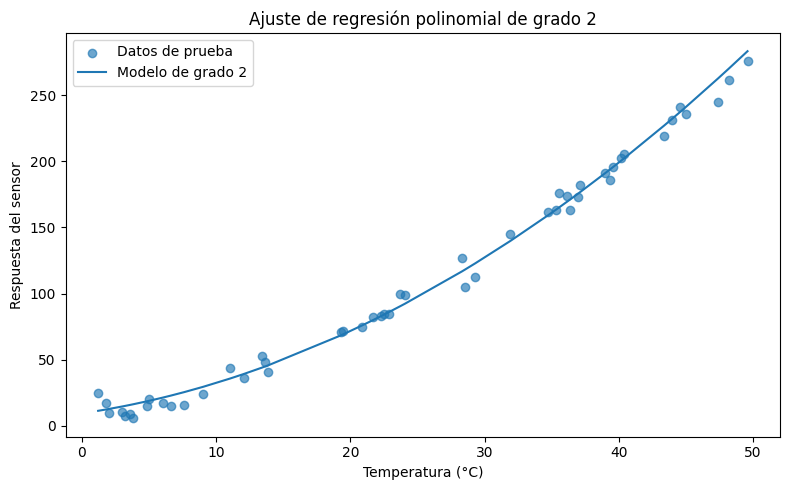

In [18]:
# Ordenar las temperaturas de prueba para dibujar una curva continua.
orden = np.argsort(X_test["temperatura"].to_numpy())
# Obtener las temperaturas de prueba en orden ascendente.
temperaturas_ordenadas = X_test["temperatura"].to_numpy()[orden]
# Reordenar las predicciones de acuerdo con la temperatura.
predicciones_ordenadas = predicciones_grado_2[orden]
# Crear la figura de comparación.
plt.figure(figsize=(8, 5))
# Graficar las mediciones reales del conjunto de prueba.
plt.scatter(
 X_test["temperatura"],
 y_test,
 alpha=0.65,
 label="Datos de prueba"
)
# Graficar la curva estimada por el modelo polinomial.
plt.plot(
 temperaturas_ordenadas,
 predicciones_ordenadas,
 label="Modelo de grado 2"
)
# Agregar título y etiquetas.
plt.title("Ajuste de regresión polinomial de grado 2")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Respuesta del sensor")
# Mostrar la leyenda.
plt.legend()
# Ajustar el diseño.
plt.tight_layout()
# Mostrar la gráfica.
plt.show()

# **Paso 9. Entrenar modelos de grados 1, 2, 3, 5 y 10**

In [19]:
# Definir los grados polinomiales que se desean comparar.
grados = [1, 2, 3, 5, 10]
# Crear una lista para guardar las métricas de cada modelo.
resultados = []
# Crear un diccionario para almacenar los modelos entrenados.
modelos = {}
# Recorrer cada grado de la lista.
for grado in grados:
 # Crear el modelo con escalado, características polinomiales
 # y regresión lineal.
 modelo = Pipeline([
 ("escalado", StandardScaler()),
 ("polinomio", PolynomialFeatures(
 degree=grado,
 include_bias=False
 )),
 ("regresion", LinearRegression())
 ])
 # Entrenar el modelo únicamente con los datos de entrenamiento.
 modelo.fit(X_train, y_train)
 # Calcular el desempeño en el conjunto de entrenamiento.
 pred_train = modelo.predict(X_train)
 # Calcular el desempeño en el conjunto de prueba.
 pred_test = modelo.predict(X_test)
 # Calcular el RMSE de entrenamiento.
 rmse_train = np.sqrt(
 mean_squared_error(y_train, pred_train)
 )
 # Calcular el RMSE de prueba.
 rmse_test = np.sqrt(
 mean_squared_error(y_test, pred_test)
 )
 # Calcular el R² de prueba.
 r2_test = r2_score(y_test, pred_test)
 # Guardar las métricas del modelo actual.
 resultados.append({
 "Grado": grado,
 "RMSE entrenamiento": rmse_train,
 "RMSE prueba": rmse_test,
 "R² prueba": r2_test
 })
 # Guardar el modelo entrenado para utilizarlo después.
 modelos[grado] = modelo
# Convertir los resultados en una tabla.
tabla_resultados = pd.DataFrame(resultados)
# Mostrar la comparación de los grados polinomiales.
display(tabla_resultados.round(4))

,Grado,RMSE entrenamiento,RMSE prueba,R² prueba
0,1,17.2074,14.5829,0.9688
1,2,7.9223,6.7095,0.9934
2,3,7.9180,6.6754,0.9935
3,5,7.9139,6.6033,0.9936
4,10,7.8525,6.4782,0.9938


# **Paso 10. Visualizar cómo cambia la curva con el grado**

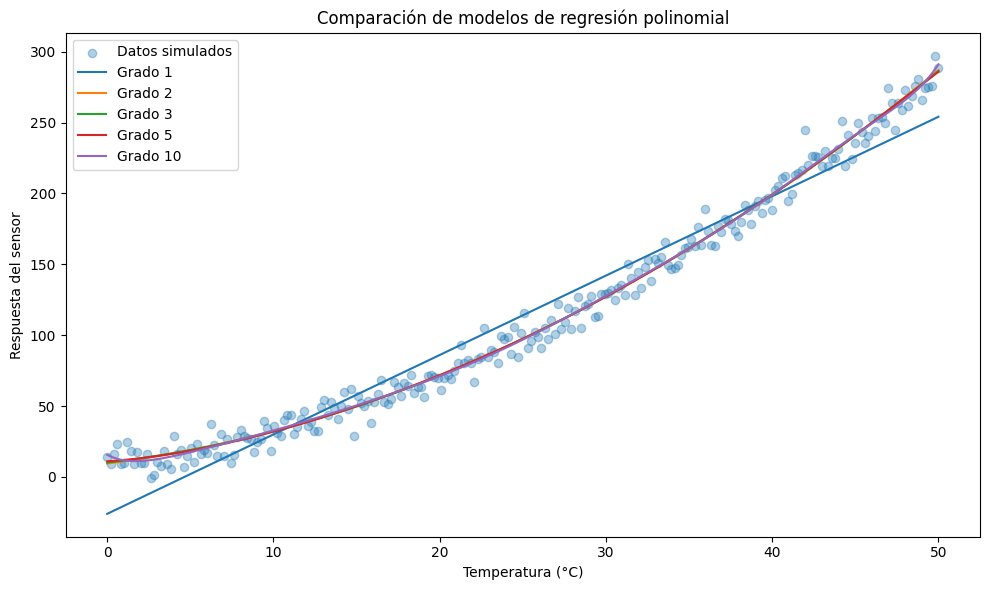

In [20]:
# Crear una secuencia de temperaturas para dibujar curvas suaves.
temperaturas_grafica = np.linspace(
 X["temperatura"].min(),
 X["temperatura"].max(),
 300
)
# Convertir la secuencia en un DataFrame con el nombre de la variable.
X_grafica = pd.DataFrame({
 "temperatura": temperaturas_grafica
})
# Crear la figura donde se compararán los modelos.
plt.figure(figsize=(10, 6))
# Mostrar todas las mediciones simuladas.
plt.scatter(
 X["temperatura"],
 y,
 alpha=0.35,
 label="Datos simulados"
)
# Graficar cada modelo con su grado correspondiente.
for grado in grados:
 # Generar predicciones sobre la secuencia ordenada.
 curva = modelos[grado].predict(X_grafica)
 # Dibujar la curva estimada.
 plt.plot(
 temperaturas_grafica,
 curva,
 label=f"Grado {grado}"
 )
# Agregar el título y las etiquetas de los ejes.
plt.title("Comparación de modelos de regresión polinomial")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Respuesta del sensor")
# Mostrar la leyenda de los modelos.
plt.legend()
# Ajustar el espacio de la gráfica.
plt.tight_layout()
# Mostrar la figura final.
plt.show()


# **8. Reto: calibración de un sensor con selección del grado polinomial**

# Actividad adicional: determinar el grado del polinomio que ofrece un equilibrio entre precisión y
complejidad.
Imagine que debe entregar un prototipo de calibración a un equipo de automatización industrial. El equipo
necesita una respuesta estimada con errores reducidos, pero también desea evitar un modelo innecesariamente
complejo.
Desarrolle las siguientes actividades:
1. Amplíe la comparación para incluir los grados 1, 2, 3, 4, 5, 6, 8 y 10.
2. Registre el RMSE de entrenamiento, el RMSE de prueba y el 𝑅
2de prueba.
3. Grafique el grado del polinomio frente al RMSE de entrenamiento y al RMSE de prueba.
4. Identifique si el error de entrenamiento continúa disminuyendo cuando aumenta el grado.
5. Determine qué grado presenta el menor RMSE de prueba entre los modelos evaluados.
6. Compare ese modelo con el de grado 2.
7. Justifique cuál elegiría para el prototipo, considerando la precisión, la complejidad y la posibilidad de
sobreajuste.

# **Código de apoyo para el reto**

In [21]:
# Definir los grados adicionales que se evaluarán.
grados_reto = [1, 2, 3, 4, 5, 6, 8, 10]
# Crear una lista para almacenar los resultados.
resultados_reto = []
# Recorrer los grados que se desean probar.
for grado in grados_reto:
 # Crear el pipeline para el grado actual.
 modelo = Pipeline([
 ("escalado", StandardScaler()),
 ("polinomio", PolynomialFeatures(
 degree=grado,
 include_bias=False
 )),
 ("regresion", LinearRegression())
 ])
 # Entrenar el modelo con los datos de entrenamiento.
 modelo.fit(X_train, y_train)
 # Obtener predicciones de entrenamiento.
 pred_train = modelo.predict(X_train)
 # Obtener predicciones de prueba.
 pred_test = modelo.predict(X_test)
 # Calcular el RMSE de entrenamiento.
 error_train = np.sqrt(
 mean_squared_error(y_train, pred_train)
 )
 # Calcular el RMSE de prueba.
 error_test = np.sqrt(
 mean_squared_error(y_test, pred_test)
 )
 # Calcular el R² sobre el conjunto de prueba.
 r2_test = r2_score(y_test, pred_test)
 # Registrar las métricas del grado actual.
 resultados_reto.append({
 "Grado": grado,
 "RMSE entrenamiento": error_train,
 "RMSE prueba": error_test,
 "R² prueba": r2_test
 })
# Convertir la lista en una tabla.
tabla_reto = pd.DataFrame(resultados_reto)
# Mostrar los resultados ordenados por grado.
display(tabla_reto.sort_values("Grado").round(4))
# Identificar el modelo con menor RMSE de prueba.
# Este criterio se usa aquí para explorar los resultados,
# pero no garantiza por sí solo la mejor generalización futura.
indice_mejor = tabla_reto["RMSE prueba"].idxmin()
# Recuperar la fila correspondiente al menor RMSE de prueba.
mejor_resultado = tabla_reto.loc[indice_mejor]
# Mostrar el grado que obtuvo el menor RMSE de prueba.
print("Grado con menor RMSE de prueba:")
print(int(mejor_resultado["Grado"]))
# Mostrar las métricas del modelo seleccionado.
display(mejor_resultado.to_frame().T)


,Grado,RMSE entrenamiento,RMSE prueba,R² prueba
0,1,17.2074,14.5829,0.9688
1,2,7.9223,6.7095,0.9934
2,3,7.9180,6.6754,0.9935
3,4,7.9176,6.6680,0.9935
4,5,7.9139,6.6033,0.9936
5,6,7.8858,6.4480,0.9939
6,8,7.8664,6.4372,0.9939
7,10,7.8525,6.4782,0.9938


Grado con menor RMSE de prueba:
8


,Grado,RMSE entrenamiento,RMSE prueba,R² prueba
6,8.0,7.866401,6.437169,0.993913


# **Visualización complementaria del reto**

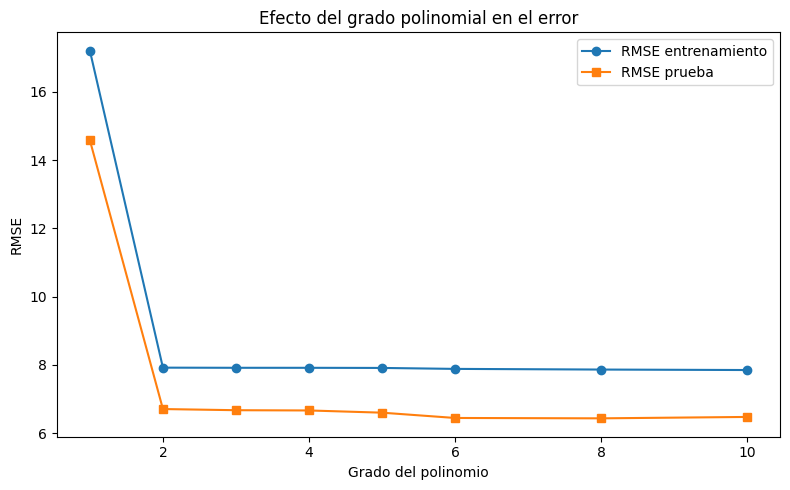

In [22]:
# Crear una figura para comparar los errores.
plt.figure(figsize=(8, 5))
# Graficar el RMSE de entrenamiento en función del grado.
plt.plot(
 tabla_reto["Grado"],
 tabla_reto["RMSE entrenamiento"],
 marker="o",
 label="RMSE entrenamiento"
)
# Graficar el RMSE de prueba en función del grado.
plt.plot(
 tabla_reto["Grado"],
 tabla_reto["RMSE prueba"],
 marker="s",
 label="RMSE prueba"
)
# Etiquetar los ejes y agregar un título.
plt.title("Efecto del grado polinomial en el error")
plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
# Mostrar la leyenda.
plt.legend()
# Ajustar el diseño.
plt.tight_layout()
# Mostrar la gráfica.
plt.show()
